In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize

# 0. Cargar Datos

In [2]:
# Cargar datos
columnas_segmentacion = ["Año", "Mes", "Cod Cliente", "Cod SKU", "Nombre Consolidado", "Zona"]
path_ventas = "datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv"
ventas = pd.read_csv(path_ventas)#, usecols=columnas_segmentacion)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_8852/2410920425.py:4: DtypeWarning: Columns (0: dscto_volumen, 1: ids_descuento_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)#, usecols=columnas_segmentacion)


Ventas - Filas: 10596574


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Distrito,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,HR,ZV01,2025-01-03,43790,NaN,55,HORECA VOLUMEN,MORTADELAS,...,SANTIAGO HORECA PAP,2715.0,-3.0,2352.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,HR,ZV01,2025-01-03,1227049,NaN,37,OTROS HORECA,VIENESAS,...,SANTIAGO HORECA PAP,2722.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1174760,NaN,32,COBERTURA,HAMBURGUESAS,...,NaN,5171.0,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,HR,ZV01,2025-01-03,1015869,NaN,55,HORECA VOLUMEN,PARRILLEROS,...,SANTIAGO HORECA PAP,3232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Factura Venta',
       'Factura Kilos', 'Kilo Real', 'Kilos Nc', 'Monto Nc', 'Monto Real',
       'Precio', 'venta_id', 'Zona', 'Distrito', 'Precio_Lista', 'dscto_base',
       'id_descuento_base', 'dscto_volumen', 'ids_descuento_volumen',
       'dscto_binario', 'id_descuento_binario', 'carta_impacto',
       'id_descuento_carta_impacto'],
      dtype='str')

In [4]:
ventas["familia_marca"] = ventas["Nombre Familia"].astype(str) + ventas["Nombre Marca"].astype(str)

In [5]:
# Filtrar canales relevantes
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    # "MAYORISTAS CADENAS",
    # "MAYORISTA B VOLUMEN",
    # "OTROS MAYORISTAS",
    # "HORECA VOLUMEN",
    # "OTROS HORECA",
]
ventas = ventas[
    (ventas["Cod Canal Comercial"] == "CB") &
    (ventas["Nombre Consolidado"].isin(canales_relevantes))
    ]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 9615996


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto,familia_marca
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SALAMESLA PREFERIDA
3,2025,1,CB,ZV01,2025-01-02,1174760,NaN,32,COBERTURA,HAMBURGUESAS,...,5171.0,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN,HAMBURGUESASLA PREFERIDA
7,2025,1,CB,ZV01,2025-01-02,1137411,NaN,54,VOLUMEN COBERTURA,HORTALIZAS,...,2198.0,-3.0,2837.0,NaN,NaN,NaN,NaN,NaN,NaN,HORTALIZASMAESTRO
9,2025,1,CB,ZV01,2025-01-02,1134837,NaN,32,COBERTURA,PATE,...,4654.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PATELA PREFERIDA
10,2025,1,CB,ZV01,2025-01-02,1114635,NaN,54,VOLUMEN COBERTURA,PATE,...,4654.0,-3.0,1277.0,NaN,NaN,NaN,NaN,NaN,NaN,PATELA PREFERIDA


In [6]:
path_info_zonales = "datos/Clientes - Zonales.xlsx"
zonales = pd.read_excel(path_info_zonales)
zonales.head()

,Id cliente,REGIONES
0,1194043,RANCAGUA
1,1155918,RANCAGUA
2,1090050,RANCAGUA
3,1203751,RANCAGUA
4,1231602,IQUIQUE


In [7]:
zonales.columns

Index(['Id cliente', 'REGIONES'], dtype='str')

In [8]:
path_clientes = "datos/Base Datos Clientes - Carga de Trabajo.xlsx"
clientes = pd.read_excel(path_clientes, header=1)
clientes.head()

,Zona,Distrito,CodJV,CodSup,CodVend,NombreVendedor,Canal,SubCanal,CodCliente Padre,Cliente Padre,...,MA,MI,JU,VI,SA,Frecuencia,Tratamiento,CodPago,DesPago,Estado
0,SANTIAGO,SANTIAGO CENTRO COSTA,854,854,1084869,ALEXIS PEREZ MUÑOZ,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.0,1.0,0,1.0,Cliente,C005,FIRMA 7 DIAS,1
1,SUR 1,RANCAGUA,481,481,482,JUAN FARIAS PEREZ,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.0,0.0,0,0.5,Cliente,C000,EFECTIVO - CHEQUE AL DIA,1
2,SUR 2,CONCEPCION SUR,1178566,1178566,1084857,ALEX RIOS CUEVAS,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.5,0.0,0,0.5,Cliente,C017,EFECTIVO,1
3,SUR 1,TALCA,581,581,1160963,RODRIGO AVENDAÑO HERNANDEZ,COBERTURA,COBERTURA,0,-,...,0.0,1.0,0.0,0.0,0,1.0,Cliente,C044,PAGO ELECT CREDITO 07 DIAS,1
4,NORTE 2,VIÑA COSTA,1216438,1216438,1206012,PAULO RUZ BILBAO,COBERTURA,COBERTURA,0,-,...,1.0,0.0,0.0,1.0,0,2.0,Cliente,C044,PAGO ELECT CREDITO 07 DIAS,1


In [9]:
clientes.columns

Index(['Zona', 'Distrito', 'CodJV', 'CodSup', 'CodVend', 'NombreVendedor',
       'Canal', 'SubCanal', 'CodCliente Padre', 'Cliente Padre', 'CodCliente',
       'RazonSocial', 'Direccion', 'Comuna', 'TipoNeg', 'DesTipoNeg', 'Relev',
       'NivPrecio', 'Telefono', 'Correo', 'VtaUlt3M', 'PromUlt3M',
       'Margen3ULTM', 'PromMargen3ULTM', 'CodRuta', 'DesRuta', 'NroSec',
       'RitmoVisita', 'LU', 'MA', 'MI', 'JU', 'VI', 'SA', 'Frecuencia',
       'Tratamiento', 'CodPago', 'DesPago', 'Estado'],
      dtype='str')

In [10]:
path_segmentacion_prods = "datos/segmentacion_productos.xlsx"
segmentacion_productos = pd.read_excel(path_segmentacion_prods)
nombres_sku = (
    segmentacion_productos[["sku", "descripción"]]
    .drop_duplicates(subset="sku")
    .set_index("sku")["descripción"]
)

# 1. Cruces de bases y filtros

In [11]:
ventas = ventas.merge(zonales[["Id cliente", "REGIONES"]].rename(columns={"Id cliente": "Cod Cliente", "REGIONES": "zonal"}), on="Cod Cliente", how="left")

In [12]:
# Filtrar a solo segundo semestre de 2025
ventas = ventas[ventas["Año"] == 2025]
ventas = ventas[ventas["Mes"] >= 7]
print("Ventas después de filtrar fechas - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar fechas - Filas: 3813911


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto,familia_marca,zonal
37,2025,8,CB,ZV01,2025-08-18,1037715,NaN,54,VOLUMEN COBERTURA,TIPICOS,...,-3.0,2086.0,NaN,NaN,NaN,NaN,NaN,NaN,TIPICOSLA PREFERIDA,ANTOFAGASTA
41,2025,8,CB,ZV01,2025-08-15,1217828,NaN,32,COBERTURA,TIPICOS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TIPICOSLA PREFERIDA,TEMUCO
50,2025,10,CB,ZV01,2025-10-06,1230617,NaN,32,COBERTURA,QUESOS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QUESOSLos Nogales,VIÑA DEL MAR
51,2025,10,CB,ZV01,2025-10-06,239801,NaN,54,VOLUMEN COBERTURA,QUESOS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QUESOSLos Nogales,
57,2025,12,CB,ZV01,2025-12-27,1201468,NaN,32,COBERTURA,MORTADELAS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MORTADELASWINTER,TEMUCO


In [13]:
# Excluir clientes por TipoNeg antes de armar la matriz cliente-SKU
tipos_neg_excluidos = ["MO", "SN", "SR", "CD", "CZ", "DG", "EC", "PC", "HR"]
path_clientes = "datos/Base Datos Clientes - Carga de Trabajo.xlsx"
clientes_tiponeg = pd.read_excel(path_clientes, header=1, usecols=["CodCliente", "TipoNeg"])

ventas = ventas.merge(
    clientes_tiponeg.drop_duplicates(subset=["CodCliente"]),
    left_on="Cod Cliente",
    right_on="CodCliente",
    how="left",
)
ventas = ventas.loc[~ventas["TipoNeg"].isin(tipos_neg_excluidos)].drop(columns=["CodCliente", "TipoNeg"])
print("Ventas después de filtrar TipoNeg excluidos - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar TipoNeg excluidos - Filas: 3813911


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto,familia_marca,zonal
0,2025,8,CB,ZV01,2025-08-18,1037715,NaN,54,VOLUMEN COBERTURA,TIPICOS,...,-3.0,2086.0,NaN,NaN,NaN,NaN,NaN,NaN,TIPICOSLA PREFERIDA,ANTOFAGASTA
1,2025,8,CB,ZV01,2025-08-15,1217828,NaN,32,COBERTURA,TIPICOS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TIPICOSLA PREFERIDA,TEMUCO
2,2025,10,CB,ZV01,2025-10-06,1230617,NaN,32,COBERTURA,QUESOS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QUESOSLos Nogales,VIÑA DEL MAR
3,2025,10,CB,ZV01,2025-10-06,239801,NaN,54,VOLUMEN COBERTURA,QUESOS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,QUESOSLos Nogales,
4,2025,12,CB,ZV01,2025-12-27,1201468,NaN,32,COBERTURA,MORTADELAS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MORTADELASWINTER,TEMUCO


In [14]:
ventas = ventas[ventas["Cod Canal Comercial"]=="CB"]
ventas["Cod Canal Comercial"].value_counts()

Cod Canal Comercial
CB    3813911
Name: count, dtype: int64

# 2. Crear segmentación (Funciones)

In [15]:
parametros_kmeans = {
    "random_state": 42,
    "batch_size": 4096,
    "n_init": "auto",
}

In [16]:
def preparar(
        ventas_df,
        columna_producto,
        conteo_compra,
        verbosity=False
):
    # Armar matriz cliente-SKU
    if not isinstance(ventas_df, pd.DataFrame):
        raise TypeError("ventas_df debe ser un DataFrame de pandas. Reejecuta las celdas de preparación de ventas.")
    cols = ["Cod Cliente", columna_producto]
    columnas_faltantes = [col for col in cols if col not in ventas_df.columns]
    if columnas_faltantes:
        raise KeyError(f"Columnas faltantes en ventas_df: {columnas_faltantes}")
    
    # 1 si compró alguna vez en los últimos 6 meses
    if conteo_compra == "binario":
        compras_cliente_sku = ventas_df[cols].drop_duplicates()
        matriz_cliente_sku = pd.crosstab(
            compras_cliente_sku["Cod Cliente"],
            compras_cliente_sku[columna_producto],
        ).astype(np.uint8)

    # Conteo de veces que compró en los últimos 6 meses
    elif conteo_compra == "conteo":
        compras_cliente_sku = ventas_df[cols]
        matriz_cliente_sku = pd.crosstab(
            compras_cliente_sku["Cod Cliente"],
            compras_cliente_sku[columna_producto],
        ).astype(np.uint8)

    # Porcentaje de la cantidad de compras
    elif conteo_compra == "pg_compras":
        compras_cliente_sku = ventas_df[cols]
        matriz_cliente_sku = pd.crosstab(
            compras_cliente_sku["Cod Cliente"],
            compras_cliente_sku[columna_producto],
        )
        matriz_cliente_sku = matriz_cliente_sku.div(
            matriz_cliente_sku.sum(axis=1),
            axis=0
        ).fillna(0)
        matriz_cliente_sku = matriz_cliente_sku.astype(np.float32)

    # Porcentaje de los ingresos
    elif conteo_compra == "pg_ingresos": 
        compras_cliente_sku = ventas_df[["Cod Cliente", columna_producto, "Monto Real"]].copy()
        matriz_cliente_sku = (
            compras_cliente_sku
            .groupby(["Cod Cliente", columna_producto])["Monto Real"]
            .sum()
            .unstack(fill_value=0)
        )
        matriz_cliente_sku = matriz_cliente_sku.div(
            matriz_cliente_sku.sum(axis=1),
            axis=0
        ).fillna(0)
        matriz_cliente_sku = matriz_cliente_sku.astype(np.float32)

    else:
        raise ValueError(f"conteo_compra no soportado: {conteo_compra}")
    if verbosity:
        print("Matriz cliente-SKU:", matriz_cliente_sku.shape)
        display(matriz_cliente_sku.head())
    
    return matriz_cliente_sku

In [17]:
def segmentar(
        matriz_cliente_sku,
        k,      # kmeans
        verbosity=False     # Mostrar proceso o no
):
    # Normalizar aproxima clustering por similitud coseno sin construir una matriz cliente-cliente
    X_clientes = csr_matrix(matriz_cliente_sku.to_numpy(dtype=np.float32))
    X_clientes = normalize(X_clientes, norm="l2", copy=False)
    if verbosity:
        print("Matriz sparse normalizada:", X_clientes.shape, "nnz=", X_clientes.nnz)

    modelo_clusters = MiniBatchKMeans(
        n_clusters=k,
        **parametros_kmeans,
    )
    clusters = modelo_clusters.fit_predict(X_clientes) + 1

    segmentacion_clientes = pd.DataFrame({
        "Cod Cliente": matriz_cliente_sku.index,
        "cluster": clusters,
    })
    return segmentacion_clientes

In [18]:
def obtener_canasta(
        cluster_elegido,
        matriz_cliente_sku,
        segmentacion_clientes,
        granularidad_sku,    # Familia, Familia-marca, Subfamilia, SKU
        umbral=0.5,          # A partir de qué porcentaje de pertenencia considero un producto como miembro de la canasta
        verbosity=False
):
    # La canasta siempre se calcula sobre soporte binario para que sea comparable entre segmentaciones.
    matriz_cliente_sku_binario = matriz_cliente_sku.gt(0).astype(np.uint8)
    clientes_cluster = segmentacion_clientes[segmentacion_clientes["cluster"] == cluster_elegido]["Cod Cliente"]
    skus_cluster = matriz_cliente_sku_binario.loc[clientes_cluster]

    tabla_skus_comunes_cluster = (
        skus_cluster.sum()
        .sort_values(ascending=False)
        .rename_axis(granularidad_sku)
        .reset_index(name="conteo_clientes")
    )
    if granularidad_sku == "Cod SKU":
        tabla_skus_comunes_cluster["nombre_sku"] = (
            tabla_skus_comunes_cluster["Cod SKU"].map(nombres_sku).fillna("SKU sin descripcion")
        )
    cantidad_clientes_cluster = len(clientes_cluster)
    tabla_skus_comunes_cluster["porcentaje_clientes_cluster"] = (
        tabla_skus_comunes_cluster["conteo_clientes"] / cantidad_clientes_cluster
    )
    tabla_skus_comunes_cluster = tabla_skus_comunes_cluster[
        [granularidad_sku, "conteo_clientes", "porcentaje_clientes_cluster"]
    ]

    if verbosity:
        display(tabla_skus_comunes_cluster.head(n=20))

    skus_canasta = tabla_skus_comunes_cluster[
        tabla_skus_comunes_cluster["porcentaje_clientes_cluster"] > umbral
    ][granularidad_sku].unique()

    if verbosity:
        print(f"Canasta del cluster: {skus_canasta}")

    return skus_canasta

In [19]:
# Agrega esta helper y reemplaza tu función evaluar_segmentaciones por esta versión

def calcular_pesos_penetracion_global(matriz_cliente_sku, exponente=0.5):
    matriz_cliente_sku_binario = matriz_cliente_sku.gt(0).astype(np.uint8)
    return matriz_cliente_sku_binario.mean(axis=0).pow(exponente)


def evaluar_segmentaciones(
        ventas_df,
        matriz_cliente_sku,
        ks_clustering,
        granularidad_sku,
        conteo_compra,
        umbral=0.5,
        verbosity=False,
        pesos_penetracion_global=None,
        exponente_penetracion=0.5,
):
    X_clientes = csr_matrix(matriz_cliente_sku.to_numpy(dtype=np.float32))
    X_clientes = normalize(X_clientes, norm="l2", copy=False)
    if verbosity:
        print("Matriz sparse normalizada:", X_clientes.shape, "nnz=", X_clientes.nnz)

    # El clustering usa la representación elegida por conteo_compra, pero los scores
    # de canastas siempre comparan canastas definidas sobre soporte binario común.
    matriz_cliente_sku_binario = matriz_cliente_sku.gt(0).astype(np.uint8)

    # Estos pesos se pueden calcular una sola vez por matriz para eficiencia
    if pesos_penetracion_global is None:
        pesos_penetracion_global = calcular_pesos_penetracion_global(
            matriz_cliente_sku,
            exponente=exponente_penetracion,
        )

    pesos_penetracion_global = (
        pesos_penetracion_global
        .reindex(matriz_cliente_sku.columns)
        .fillna(0.0)
        .astype(float)
    )
    peso_total_universo = pesos_penetracion_global.sum()

    k_max = X_clientes.shape[0] - 1
    rango_clusters = [k for k in ks_clustering if 2 <= k <= k_max]
    if not rango_clusters:
        raise ValueError(
            f"No hay valores validos en ks_clustering para {X_clientes.shape[0]} clientes. Usa k entre 2 y {k_max}."
        )

    tamano_muestra_silhouette = min(30000, X_clientes.shape[0])
    if verbosity:
        print(f"Calculando silhouette sobre una muestra de {tamano_muestra_silhouette} clientes")

    resultados_segmentacion = []
    for k in rango_clusters:
        modelo_tmp = MiniBatchKMeans(
            n_clusters=k,
            **parametros_kmeans,
        )
        labels_tmp = modelo_tmp.fit_predict(X_clientes)

        score_silhouette = silhouette_score(
            X_clientes,
            labels_tmp,
            metric="cosine",
            sample_size=tamano_muestra_silhouette,
            random_state=42,
        )

        segmentacion_clientes = pd.DataFrame({
            "Cod Cliente": matriz_cliente_sku.index,
            "cluster": labels_tmp + 1,
        })

        clusters = sorted(segmentacion_clientes["cluster"].unique())
        tamanos_cluster = segmentacion_clientes["cluster"].value_counts().to_dict()

        canastas = {}
        for cluster in clusters:
            canastas[cluster] = set(
                obtener_canasta(
                    cluster,
                    matriz_cliente_sku_binario,
                    segmentacion_clientes,
                    granularidad_sku,
                    umbral=umbral,
                    verbosity=False,
                )
            )

        scores_canastas = []
        pesos_pares = []
        for i, cluster_1 in enumerate(clusters):
            canasta_1 = canastas[cluster_1]
            for cluster_2 in clusters[i + 1:]:
                canasta_2 = canastas[cluster_2]
                union = canasta_1 | canasta_2

                if not union:
                    score_par = 0.0
                else:
                    jaccard = len(canasta_1 & canasta_2) / len(union)
                    score_par = 1 - jaccard

                scores_canastas.append(score_par)
                pesos_pares.append(tamanos_cluster[cluster_1] * tamanos_cluster[cluster_2])

        score_canastas = np.mean(scores_canastas) if scores_canastas else 0.0
        score_canastas_ponderado = (
            np.average(scores_canastas, weights=pesos_pares)
            if scores_canastas else 0.0
        )

        skus_cubiertos = set()
        for canasta in canastas.values():
            skus_cubiertos.update(canasta)

        coverage_score = (
            pesos_penetracion_global.reindex(list(skus_cubiertos)).fillna(0.0).sum() / peso_total_universo
            if peso_total_universo > 0 and skus_cubiertos else 0.0
        )

        score_armonico = (
            2 * score_canastas_ponderado * coverage_score / (score_canastas_ponderado + coverage_score)
            if (score_canastas_ponderado + coverage_score) > 0 else 0.0
        )

        resultados_segmentacion.append({
            "k": k,
            "silhouette_score": score_silhouette,
            "score_canastas": score_canastas,
            "score_canastas_ponderado": score_canastas_ponderado,
            "coverage_score": coverage_score,
            "score_armonico": score_armonico,
        })

        if verbosity:
            print(
                f"k={k}: silhouette={score_silhouette:.4f}, "
                f"score_canastas={score_canastas:.4f}, "
                f"score_canastas_ponderado={score_canastas_ponderado:.4f}, "
                f"coverage={coverage_score:.4f}, "
                f"score_armonico={score_armonico:.4f}"
            )

    return pd.DataFrame(resultados_segmentacion).sort_values("k").reset_index(drop=True)

In [20]:
# Reemplaza tu función graficar_resultado por esta versión

def graficar_resultado(resultados_segmentacion):
    resultados_plot = resultados_segmentacion.sort_values("k").reset_index(drop=True)

    idx_silhouette = resultados_plot["silhouette_score"].idxmax()
    idx_armonico = resultados_plot["score_armonico"].idxmax()

    k_silhouette = int(resultados_plot.loc[idx_silhouette, "k"])
    k_armonico = int(resultados_plot.loc[idx_armonico, "k"])

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    color_silhouette = "tab:blue"
    color_armonico = "tab:orange"

    linea_silhouette = ax1.plot(
        resultados_plot["k"],
        resultados_plot["silhouette_score"],
        color=color_silhouette,
        marker="o",
        label="Silhouette score",
    )
    linea_armonico = ax2.plot(
        resultados_plot["k"],
        resultados_plot["score_armonico"],
        color=color_armonico,
        marker="s",
        label="Score armónico",
    )

    ax1.scatter(
        resultados_plot.loc[idx_silhouette, "k"],
        resultados_plot.loc[idx_silhouette, "silhouette_score"],
        color=color_silhouette,
        s=100,
        zorder=5,
    )
    ax2.scatter(
        resultados_plot.loc[idx_armonico, "k"],
        resultados_plot.loc[idx_armonico, "score_armonico"],
        color=color_armonico,
        s=100,
        zorder=5,
    )

    ax1.axvline(k_silhouette, color=color_silhouette, linestyle="--", alpha=0.5)
    ax1.axvline(k_armonico, color=color_armonico, linestyle=":", alpha=0.5)

    ax1.annotate(
        f"k óptimo silhouette = {k_silhouette}",
        xy=(resultados_plot.loc[idx_silhouette, "k"], resultados_plot.loc[idx_silhouette, "silhouette_score"]),
        xytext=(8, 8),
        textcoords="offset points",
        color=color_silhouette,
    )
    ax2.annotate(
        f"k óptimo score armónico = {k_armonico}",
        xy=(resultados_plot.loc[idx_armonico, "k"], resultados_plot.loc[idx_armonico, "score_armonico"]),
        xytext=(8, -14),
        textcoords="offset points",
        color=color_armonico,
    )

    ax1.set_xlabel("Número de clusters (k)")
    ax1.set_ylabel("Silhouette score", color=color_silhouette)
    ax2.set_ylabel("Score armónico", color=color_armonico)
    ax1.tick_params(axis="y", labelcolor=color_silhouette)
    ax2.tick_params(axis="y", labelcolor=color_armonico)
    ax1.set_title("Scores de segmentación según k")

    lineas = linea_silhouette + linea_armonico
    labels = [linea.get_label() for linea in lineas]
    ax1.legend(lineas, labels, loc="best")

    plt.tight_layout()
    plt.show()

In [21]:
def tabla_negocio_cluster (segmentacion_clientes):
    segmentacion_tiponeg = segmentacion_clientes.copy()
    segmentacion_tiponeg = segmentacion_tiponeg.merge(clientes[["CodCliente", "DesTipoNeg"]], left_on="Cod Cliente", right_on="CodCliente", how="left")
    segmentacion_tiponeg.drop(columns=["CodCliente"], inplace=True)
    segmentacion_tiponeg["DesTipoNeg"] = segmentacion_tiponeg["DesTipoNeg"].fillna("Sin TipoNeg")

    clusters_ordenados = sorted(segmentacion_tiponeg["cluster"].dropna().unique())

    tabla_tiponeg_cluster = (
        pd.crosstab(
            segmentacion_tiponeg["DesTipoNeg"],
            segmentacion_tiponeg["cluster"],
            normalize="index",
        )
        .reindex(columns=clusters_ordenados, fill_value=0)
        .mul(100)
        .round(1)
    )

    tabla_tiponeg_cluster.columns = [f"Cluster {int(col)}" for col in tabla_tiponeg_cluster.columns]

    cluster_predominante = tabla_tiponeg_cluster.idxmax(axis=1)
    porcentaje_predominante = tabla_tiponeg_cluster.max(axis=1)

    tabla_tiponeg_cluster["Cluster predominante (%)"] = (
        cluster_predominante
        + " ("
        + porcentaje_predominante.round(1).astype(str)
        + "%)"
    )

    return tabla_tiponeg_cluster

In [22]:
def tabla_cluster_negocio(segmentacion_clientes):
    segmentacion_tiponeg = segmentacion_clientes.copy()

    segmentacion_tiponeg = segmentacion_tiponeg.merge(
        clientes[["CodCliente", "DesTipoNeg"]],
        left_on="Cod Cliente",
        right_on="CodCliente",
        how="left",
    )

    segmentacion_tiponeg.drop(columns=["CodCliente"], inplace=True)

    segmentacion_tiponeg["DesTipoNeg"] = (
        segmentacion_tiponeg["DesTipoNeg"]
        .fillna("Sin TipoNeg")
    )

    clusters_ordenados = sorted(
        segmentacion_tiponeg["cluster"].dropna().unique()
    )

    tipos_negocio_ordenados = sorted(
        segmentacion_tiponeg["DesTipoNeg"].dropna().unique()
    )

    tabla_cluster_tiponeg = (
        pd.crosstab(
            segmentacion_tiponeg["cluster"],
            segmentacion_tiponeg["DesTipoNeg"],
            normalize="index",
        )
        .reindex(index=clusters_ordenados, fill_value=0)
        .reindex(columns=tipos_negocio_ordenados, fill_value=0)
        .mul(100)
        .round(1)
    )

    tabla_cluster_tiponeg.index = [
        f"Cluster {int(cluster)}"
        for cluster in tabla_cluster_tiponeg.index
    ]

    tipo_negocio_predominante = tabla_cluster_tiponeg.idxmax(axis=1)
    porcentaje_predominante = tabla_cluster_tiponeg.max(axis=1)

    tabla_cluster_tiponeg["Tipo negocio principal (%)"] = (
        tipo_negocio_predominante
        + " ("
        + porcentaje_predominante.round(1).astype(str)
        + "%)"
    )

    return tabla_cluster_tiponeg

In [23]:
def tabla_canastas_clusters(
        matriz_cliente_sku,
        segmentacion_clientes,
        granularidad_sku="Cod SKU",
        umbral=0.5,
        mapa_nombres_sku=None,
):
    if granularidad_sku != "Cod SKU":
        raise ValueError("tabla_canastas_clusters solo esta definida para granularidad_sku='Cod SKU'.")

    if mapa_nombres_sku is None:
        mapa_nombres_sku = nombres_sku

    columnas_salida = [
        "cluster",
        "Cod SKU",
        "Nombre SKU",
        "conteo_clientes",
        "porcentaje_clientes_cluster",
    ]

    matriz_cliente_sku_binario = matriz_cliente_sku.gt(0).astype(np.uint8)
    clusters_ordenados = sorted(segmentacion_clientes["cluster"].dropna().unique())
    tablas_clusters = []

    for cluster in clusters_ordenados:
        clientes_cluster = segmentacion_clientes.loc[
            segmentacion_clientes["cluster"] == cluster,
            "Cod Cliente",
        ]
        clientes_cluster = clientes_cluster[clientes_cluster.isin(matriz_cliente_sku_binario.index)]
        cantidad_clientes_cluster = len(clientes_cluster)

        if cantidad_clientes_cluster == 0:
            continue

        tabla_cluster = (
            matriz_cliente_sku_binario.loc[clientes_cluster]
            .sum()
            .sort_values(ascending=False)
            .rename_axis("Cod SKU")
            .reset_index(name="conteo_clientes")
        )
        tabla_cluster["porcentaje_clientes_cluster"] = (
            tabla_cluster["conteo_clientes"] / cantidad_clientes_cluster
        )
        tabla_cluster = tabla_cluster[
            tabla_cluster["porcentaje_clientes_cluster"] > umbral
        ].copy()

        if tabla_cluster.empty:
            continue

        tabla_cluster.insert(0, "cluster", cluster)
        tabla_cluster["Nombre SKU"] = (
            tabla_cluster["Cod SKU"].map(mapa_nombres_sku).fillna("SKU sin descripcion")
        )
        tabla_cluster = tabla_cluster[columnas_salida]
        tablas_clusters.append(tabla_cluster)

    if not tablas_clusters:
        return pd.DataFrame(columns=columnas_salida)

    return pd.concat(tablas_clusters, ignore_index=True)

# 3. Iteración de Segmentaciones

## 3.1 Por SKU

In [24]:
# Iteramos la clusterización
granularidad_sku = "Cod SKU" # "familia_marca"#"Cod SKU"             # Familia, Familia-marca, Subfamilia, SKU
conteo_compra = "conteo" # "conteo" # "binario"
verbosity = True
umbral = 0.5

matriz_cliente_sku = preparar(
    ventas,
    granularidad_sku,
    conteo_compra,
    True,
)

Matriz cliente-SKU: (38501, 230)


Cod SKU,20,27,30,102,151,210,215,217,253,254,...,8454,8463,8508,8516,8517,8630,8753,8777,8798,8991
Cod Cliente,,,,,,,,,,,,,,,,,,,,,
235,2,0,3,0,0,2,0,0,0,0,...,0,0,11,0,0,0,0,0,0,0
499,0,0,0,0,0,0,0,0,0,0,...,0,0,15,0,0,0,0,1,0,0
547,0,0,0,0,0,8,0,0,0,0,...,3,1,21,0,0,0,0,26,0,0
665,12,1,0,0,6,25,0,0,0,0,...,0,0,0,0,0,0,0,0,11,0
1012,0,0,0,6,0,0,0,0,0,0,...,0,0,0,9,0,0,0,0,0,0


In [99]:
# En cada bloque donde llamas a evaluar_segmentaciones, agrega el pre-cálculo de pesos
# y pásalo a la función. Ejemplo:

ks_clustering = range(5, 15)

pesos_penetracion_global = calcular_pesos_penetracion_global(matriz_cliente_sku)

resultados_segmentacion = evaluar_segmentaciones(
    ventas,
    matriz_cliente_sku,
    ks_clustering,
    granularidad_sku,
    conteo_compra,
    umbral=umbral,
    verbosity=verbosity,
    pesos_penetracion_global=pesos_penetracion_global,
)

Matriz sparse normalizada: (38501, 230) nnz= 786299
Calculando silhouette sobre una muestra de 30000 clientes
k=5: silhouette=0.0814, score_canastas=0.6799, score_canastas_ponderado=0.6867, coverage=0.1434, score_armonico=0.2373
k=6: silhouette=0.0912, score_canastas=0.7487, score_canastas_ponderado=0.7707, coverage=0.1647, score_armonico=0.2714
k=7: silhouette=0.0893, score_canastas=0.6970, score_canastas_ponderado=0.6881, coverage=0.1666, score_armonico=0.2683
k=8: silhouette=0.0980, score_canastas=0.6841, score_canastas_ponderado=0.6805, coverage=0.2203, score_armonico=0.3329
k=9: silhouette=0.1010, score_canastas=0.6662, score_canastas_ponderado=0.6625, coverage=0.2317, score_armonico=0.3434
k=10: silhouette=0.1075, score_canastas=0.7406, score_canastas_ponderado=0.7695, coverage=0.2612, score_armonico=0.3900
k=11: silhouette=0.1074, score_canastas=0.7340, score_canastas_ponderado=0.7406, coverage=0.2830, score_armonico=0.4095
k=12: silhouette=0.1064, score_canastas=0.7356, score_c

In [100]:
resultados_segmentacion

,k,silhouette_score,score_canastas,score_canastas_ponderado,coverage_score,score_armonico
0,5,0.081382,0.679881,0.686696,0.143420,0.237282
1,6,0.091223,0.748730,0.770655,0.164708,0.271410
2,7,0.089275,0.696954,0.688052,0.166637,0.268296
3,8,0.097989,0.684085,0.680471,0.220320,0.332866
4,9,0.100955,0.666196,0.662454,0.231735,0.343359
5,10,0.107502,0.740589,0.769472,0.261186,0.389994
6,11,0.107422,0.733997,0.740583,0.282994,0.409507
7,12,0.106353,0.735575,0.737895,0.282994,0.409094
8,13,0.103737,0.758531,0.746043,0.287689,0.415250
9,14,0.092409,0.749942,0.742469,0.287689,0.414694


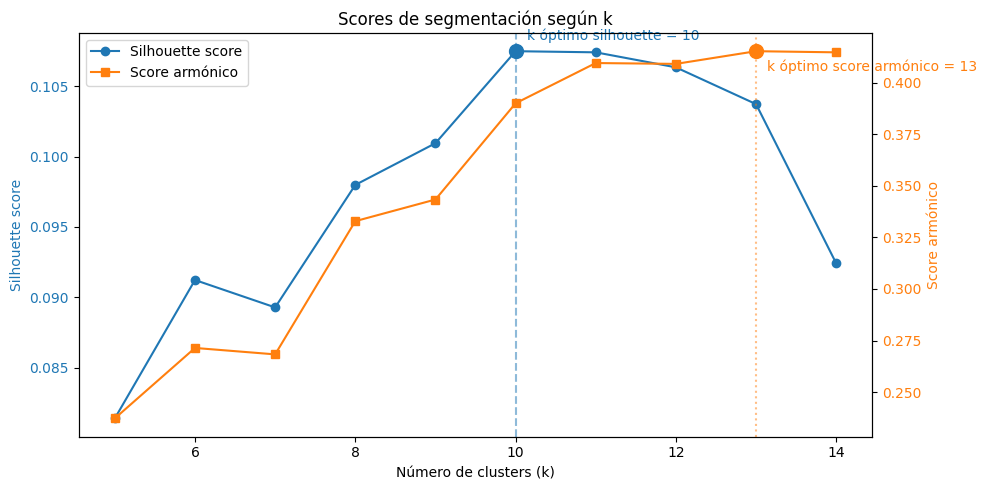

In [101]:
graficar_resultado(resultados_segmentacion)

In [102]:
k_elegido = 13
segmentacion_clientes = segmentar(
    matriz_cliente_sku,
    k_elegido,
    verbosity=verbosity,
)

Matriz sparse normalizada: (38501, 230) nnz= 786299


In [103]:
# Tabla con porcentaje de clientes por TipoNeg en cada cluster
tabla_negocio_cluster (segmentacion_clientes)

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11,Cluster 12,Cluster 13,Cluster predominante (%)
DesTipoNeg,,,,,,,,,,,,,,
AL - ALMACÉN,6.1,8.7,11.0,7.0,5.0,12.4,6.9,6.3,7.9,7.0,11.0,6.7,4.0,Cluster 6 (12.4%)
CA - CARNICERÍA,8.2,4.7,5.1,5.8,1.4,7.9,2.5,4.3,2.3,44.6,7.5,3.3,2.4,Cluster 10 (44.6%)
FI - FIAMBRERÍA,16.2,10.0,4.4,5.0,0.6,11.2,1.9,16.2,3.8,19.4,3.1,5.0,3.1,Cluster 10 (19.4%)
FS - FUENTEDE SODA,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cluster 1 (100.0%)
MA - MAYORISTA,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cluster 1 (100.0%)
MK - MINIMARKET,4.7,22.2,3.5,4.0,11.1,8.7,3.7,9.8,2.8,8.2,4.2,2.4,14.7,Cluster 2 (22.2%)
PA - PANADERÍA,5.8,15.8,6.7,4.5,1.6,16.8,7.5,17.3,8.4,4.0,1.5,5.3,4.8,Cluster 8 (17.3%)
PZ - PIZZERIA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,Cluster 10 (100.0%)
SL - SUPERMERCADO LOCAL,1.4,29.5,0.5,0.5,10.1,9.7,1.0,5.8,0.5,28.0,0.5,0.5,12.1,Cluster 2 (29.5%)


In [81]:
tabla_cluster_negocio(segmentacion_clientes)

DesTipoNeg,AL - ALMACÉN,CA - CARNICERÍA,FI - FIAMBRERÍA,FS - FUENTEDE SODA,MA - MAYORISTA,MK - MINIMARKET,PA - PANADERÍA,PZ - PIZZERIA,SL - SUPERMERCADO LOCAL,Sin TipoNeg,Tipo negocio principal (%)
Cluster 1,78.0,3.1,1.2,0.0,0.0,2.5,5.8,0.0,0.1,9.2,AL - ALMACÉN (78.0%)
Cluster 2,71.6,1.2,0.5,0.0,0.0,7.8,11.1,0.0,1.9,6.0,AL - ALMACÉN (71.6%)
Cluster 3,85.3,1.2,0.2,0.0,0.0,1.1,4.2,0.0,0.0,8.1,AL - ALMACÉN (85.3%)
Cluster 4,80.9,2.0,0.3,0.0,0.0,1.8,4.6,0.0,0.0,10.3,AL - ALMACÉN (80.9%)
Cluster 5,82.1,0.7,0.1,0.0,0.0,7.2,2.3,0.0,1.2,6.5,AL - ALMACÉN (82.1%)
Cluster 6,79.8,1.5,0.4,0.0,0.0,2.2,9.0,0.0,0.5,6.7,AL - ALMACÉN (79.8%)
Cluster 7,83.1,0.9,0.1,0.0,0.0,1.7,7.3,0.0,0.1,6.8,AL - ALMACÉN (83.1%)
Cluster 8,70.7,1.5,1.0,0.0,0.0,4.3,15.5,0.0,0.4,6.6,AL - ALMACÉN (70.7%)
Cluster 9,79.3,0.8,0.3,0.0,0.0,1.3,8.5,0.0,0.0,9.8,AL - ALMACÉN (79.3%)
Cluster 10,65.9,11.7,0.9,0.0,0.0,2.6,2.7,0.0,1.6,14.6,AL - ALMACÉN (65.9%)


In [107]:
tabla_canastas_clusters_sku = tabla_canastas_clusters(
    matriz_cliente_sku,
    segmentacion_clientes,
    granularidad_sku=granularidad_sku,
    umbral=umbral,
    mapa_nombres_sku=nombres_sku,
)

tabla_canastas_clusters_sku

,cluster,Cod SKU,Nombre SKU,conteo_clientes,porcentaje_clientes_cluster
0,1,3456,"SALAME LAMINADO 1,6 KG LP",2363,1.000000
1,1,421,PATE TERNERA 8x125 GRS.SJ,1486,0.628862
2,1,1020,VIENESA TRADICIONAL 20X250 GR SJ,1465,0.619975
3,2,399,MORTADELA LISA 3 KG SJ,3544,0.978735
4,2,421,PATE TERNERA 8x125 GRS.SJ,3151,0.870202
...,...,...,...,...,...
69,13,3034,SALAME 10x100 GR LP,1385,0.814227
70,13,6783,MANTEQUILLA 125 GRS x8 LOS NOGALES,992,0.583186
71,13,3201,JAMON PIERNA 10x200 GR LP,925,0.543798
72,13,6777,QUESO LAMINADO GAUDA 250 GR LOS NOGALES,916,0.538507


In [108]:
tabla_canastas_clusters_sku.groupby("cluster").agg({
    "Cod SKU": "count",
    "conteo_clientes": "max"
}).rename(columns={"Cod SKU": "# de SKUs"}).sort_values("conteo_clientes", ascending=False).reset_index()

,cluster,# de SKUs,conteo_clientes
0,6,9,4574
1,3,5,3916
2,11,2,3828
3,2,10,3544
4,9,4,2923
5,8,7,2691
6,4,4,2593
7,12,2,2510
8,1,3,2363
9,7,13,2337


In [113]:
segmentacion_clientes.groupby("cluster").agg({
    "Cod Cliente": "count"
}).rename({"Cod Cliente": "conteo_clientes"})

,Cod Cliente
cluster,
1,2363
2,3621
3,3916
4,2593
5,1843
6,4700
7,2520
8,2691
9,2923


In [109]:
tabla_canastas_clusters_sku[
    tabla_canastas_clusters_sku["cluster"] == 3
]

,cluster,Cod SKU,Nombre SKU,conteo_clientes,porcentaje_clientes_cluster
13,3,6770,QUESO GAUDA LAMINADO 1KG.LOS NOGALES,3916,1.000000
14,3,1020,VIENESA TRADICIONAL 20X250 GR SJ,2604,0.664964
15,3,421,PATE TERNERA 8x125 GRS.SJ,2418,0.617467
16,3,6783,MANTEQUILLA 125 GRS x8 LOS NOGALES,2258,0.576609
17,3,3313,MORTADELA JAMONADA CENTENARIO LP,2022,0.516343


In [119]:
tabla_canastas_clusters_sku[
    tabla_canastas_clusters_sku["cluster"] == 5
]

,cluster,Cod SKU,Nombre SKU,conteo_clientes,porcentaje_clientes_cluster
22,5,3034,SALAME 10x100 GR LP,1692,0.918068
23,5,1020,VIENESA TRADICIONAL 20X250 GR SJ,1384,0.750950
24,5,421,PATE TERNERA 8x125 GRS.SJ,1379,0.748237
25,5,710,HAMBURGUESA 24x90 GR SJ,1199,0.650570
26,5,2288,PAPAS FRITAS 10x1 KG SJ,1192,0.646772
27,5,689,HAMBURGUESA BRONTO 20x185 GR SJ,1118,0.606620
28,5,970,MOLIDA 14x250 GR SJ,1084,0.588171
29,5,6777,QUESO LAMINADO GAUDA 250 GR LOS NOGALES,1052,0.570808
30,5,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,1003,0.544221


In [118]:
obtener_canasta(
        5,
        matriz_cliente_sku,
        segmentacion_clientes,
        granularidad_sku,
        verbosity=True
)

,Cod SKU,conteo_clientes,porcentaje_clientes_cluster
0,3034,1692,0.918068
1,1020,1384,0.750950
2,421,1379,0.748237
3,710,1199,0.650570
4,2288,1192,0.646772
5,689,1118,0.606620
6,970,1084,0.588171
7,6777,1052,0.570808
8,3991,1003,0.544221
9,6783,911,0.494303


Canasta del cluster: [3034 1020  421  710 2288  689  970 6777 3991]


array([3034, 1020,  421,  710, 2288,  689,  970, 6777, 3991])

In [114]:
segmentacion_clientes.head()

,Cod Cliente,cluster
0,235,6
1,499,6
2,547,3
3,665,2
4,1012,5


In [122]:
mapeo_clusters_unidos = {
    1: "Salame laminado + básicos",
    2: "Mortadelas + básicos",
    9: "Mortadelas + básicos",
    3: "Queso gauda + básicos",
    4: "Queso gauda + básicos",
    5: "Salame chico / comida rápida",
    6: "Charcutería colonial/salchichón",
    8: "Charcutería colonial/salchichón",
    7: "Fiambrería tradicional surtida",
    11: "Básica vienesa-paté",
    12: "Básica vienesa-paté",
    13: "Formato chico paté-salame-lácteos",
    10: "Sin un comportamiento claro"
}
segmentacion_clientes["cluster_agrupado"] = segmentacion_clientes["cluster"].map(mapeo_clusters_unidos)
segmentacion_clientes.head()

,Cod Cliente,cluster,cluster_agrupado
0,235,6,Charcutería colonial/salchichón
1,499,6,Charcutería colonial/salchichón
2,547,3,Queso gauda + básicos
3,665,2,Mortadelas + básicos
4,1012,5,Salame chico / comida rápida


In [29]:
#segmentacion_clientes.to_csv("segmentacion_clientes_canasta.csv", index=False)
segmentacion_clientes = pd.read_csv("segmentacion_clientes_canasta.csv")
segmentacion_clientes.head()

,Cod Cliente,cluster,cluster_agrupado
0,235,6,Charcutería colonial/salchichón
1,499,6,Charcutería colonial/salchichón
2,547,3,Queso gauda + básicos
3,665,2,Mortadelas + básicos
4,1012,5,Salame chico / comida rápida


In [30]:
segmentacion_clientes['cluster_agrupado_numero'] = segmentacion_clientes['cluster_agrupado'].astype('category').cat.codes
segmentacion_clientes.head()

,Cod Cliente,cluster,cluster_agrupado,cluster_agrupado_numero
0,235,6,Charcutería colonial/salchichón,1
1,499,6,Charcutería colonial/salchichón,1
2,547,3,Queso gauda + básicos,5
3,665,2,Mortadelas + básicos,4
4,1012,5,Salame chico / comida rápida,6


In [31]:
mapeo_cluster_agrupado_numero_a_nombre = (
    segmentacion_clientes[['cluster_agrupado_numero', 'cluster_agrupado']]
    .drop_duplicates()
    .set_index('cluster_agrupado_numero')['cluster_agrupado']
    .to_dict()
)

In [ ]:
segmentacion_clientes_final = segmentacion_clientes[["Cod Cliente", "cluster_agrupado_numero"]].rename(columns={"cluster_agrupado_numero": "cluster"})

tabla_canastas_clusters_sku_final = tabla_canastas_clusters(
    matriz_cliente_sku,
    segmentacion_clientes_final,
    granularidad_sku=granularidad_sku,
    umbral=umbral,
    mapa_nombres_sku=nombres_sku,
)

tabla_canastas_clusters_sku_final["nombre_cluster"] = tabla_canastas_clusters_sku_final["cluster"].map(mapeo_cluster_agrupado_numero_a_nombre)
tabla_canastas_clusters_sku_final.head()
# tabla_canastas_clusters_sku_final.to_csv("canastas_clusters_finales.csv", index=False)

In [ ]:
# tabla_canastas_clusters_sku.to_excel("clusters_para_interpretar.xlsx")
# tabla_canastas_clusters_sku.to_csv("clusters_para_interpretar.csv")

## 3.2 Por Familia

In [32]:
# Iteramos la clusterización
granularidad_sku = "Nombre Familia"
conteo_compra = "binario"                # Binario, porcentaje de ingresos
verbosity = False
umbral = 0.5

matriz_cliente_sku = preparar(
    ventas,
    granularidad_sku,
    conteo_compra,
    verbosity,
)

In [33]:
pesos_penetracion_global = calcular_pesos_penetracion_global(matriz_cliente_sku)

resultados_segmentacion = evaluar_segmentaciones(
    ventas,
    matriz_cliente_sku,
    ks_clustering,
    granularidad_sku,
    conteo_compra,
    umbral=umbral,
    verbosity=verbosity,
    pesos_penetracion_global=pesos_penetracion_global,
)

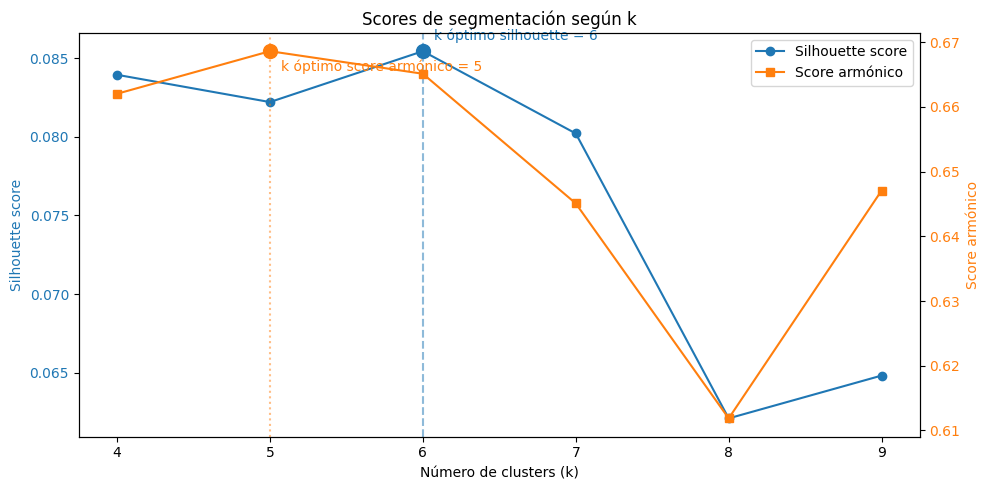

In [34]:
graficar_resultado(resultados_segmentacion)

In [35]:
k_elegido = 7
segmentacion_clientes = segmentar(
    matriz_cliente_sku,
    k_elegido,
    verbosity=verbosity,
)

In [36]:
# Tabla con porcentaje de clientes por TipoNeg en cada cluster
tabla_negocio_cluster (segmentacion_clientes)

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster predominante (%)
DesTipoNeg,,,,,,,,
AL - ALMACÉN,13.4,30.7,14.1,12.3,5.7,13.3,10.4,Cluster 2 (30.7%)
CA - CARNICERÍA,13.2,16.6,6.0,3.2,37.9,14.9,8.1,Cluster 5 (37.9%)
FI - FIAMBRERÍA,23.8,16.9,11.2,6.2,4.4,32.5,5.0,Cluster 6 (32.5%)
FS - FUENTEDE SODA,0.0,100.0,0.0,0.0,0.0,0.0,0.0,Cluster 2 (100.0%)
MA - MAYORISTA,0.0,0.0,0.0,0.0,0.0,100.0,0.0,Cluster 6 (100.0%)
MK - MINIMARKET,7.0,65.3,10.7,2.8,3.3,7.5,3.5,Cluster 2 (65.3%)
PA - PANADERÍA,32.9,24.5,6.4,5.7,1.5,25.2,3.7,Cluster 1 (32.9%)
PZ - PIZZERIA,0.0,0.0,0.0,0.0,0.0,0.0,100.0,Cluster 7 (100.0%)
SL - SUPERMERCADO LOCAL,1.9,93.2,1.0,0.0,0.0,1.9,1.9,Cluster 2 (93.2%)


In [37]:
tabla_cluster_negocio(segmentacion_clientes)

DesTipoNeg,AL - ALMACÉN,CA - CARNICERÍA,FI - FIAMBRERÍA,FS - FUENTEDE SODA,MA - MAYORISTA,MK - MINIMARKET,PA - PANADERÍA,PZ - PIZZERIA,SL - SUPERMERCADO LOCAL,Sin TipoNeg,Tipo negocio principal (%)
Cluster 1,70.7,2.0,0.7,0.0,0.0,1.4,13.9,0.0,0.1,11.2,AL - ALMACÉN (70.7%)
Cluster 2,81.3,1.3,0.2,0.0,0.0,6.8,5.2,0.0,1.7,3.5,AL - ALMACÉN (81.3%)
Cluster 3,85.6,1.1,0.4,0.0,0.0,2.5,3.1,0.0,0.0,7.3,AL - ALMACÉN (85.6%)
Cluster 4,85.0,0.6,0.2,0.0,0.0,0.8,3.2,0.0,0.0,10.2,AL - ALMACÉN (85.0%)
Cluster 5,67.3,12.9,0.3,0.0,0.0,1.5,1.4,0.0,0.0,16.6,AL - ALMACÉN (67.3%)
Cluster 6,72.1,2.3,0.9,0.0,0.0,1.6,11.0,0.0,0.1,11.9,AL - ALMACÉN (72.1%)
Cluster 7,84.1,1.9,0.2,0.0,0.0,1.1,2.4,0.0,0.1,10.1,AL - ALMACÉN (84.1%)


In [38]:
obtener_canasta(
        1,
        matriz_cliente_sku,
        segmentacion_clientes,
        granularidad_sku,
        verbosity=True
)

,Nombre Familia,conteo_clientes,porcentaje_clientes_cluster
0,LACTEOS,4909,0.852701
1,PATE,4789,0.831857
2,MORTADELAS,4723,0.820393
3,QUESOS,4573,0.794337
4,SALAMES,4416,0.767066
5,VIENESAS,3986,0.692375
6,JAMON G2,3659,0.635574
7,JAMON G1,3355,0.582769
8,SNACKS,2812,0.488449
9,ARROLLADOS,2173,0.377454


Canasta del cluster: <StringArray>
[   'LACTEOS',       'PATE', 'MORTADELAS',     'QUESOS',    'SALAMES',
   'VIENESAS',   'JAMON G2',   'JAMON G1']
Length: 8, dtype: str


<StringArray>
[   'LACTEOS',       'PATE', 'MORTADELAS',     'QUESOS',    'SALAMES',
   'VIENESAS',   'JAMON G2',   'JAMON G1']
Length: 8, dtype: str

## 3.3 Por Familia - marca

In [39]:
# Iteramos la clusterización
granularidad_sku = "familia_marca"
conteo_compra = "binario"                # Binario, porcentaje de ingresos
verbosity = False
umbral = 0.5

matriz_cliente_sku = preparar(
    ventas,
    granularidad_sku,
    conteo_compra,
    verbosity,
)

In [40]:
ks_clustering = range(4, 10)
pesos_penetracion_global = calcular_pesos_penetracion_global(matriz_cliente_sku)
resultados_segmentacion = evaluar_segmentaciones(
    ventas,
    matriz_cliente_sku,
    ks_clustering,
    granularidad_sku,
    conteo_compra,
    umbral=umbral,
    verbosity=verbosity,
    pesos_penetracion_global=pesos_penetracion_global,
)

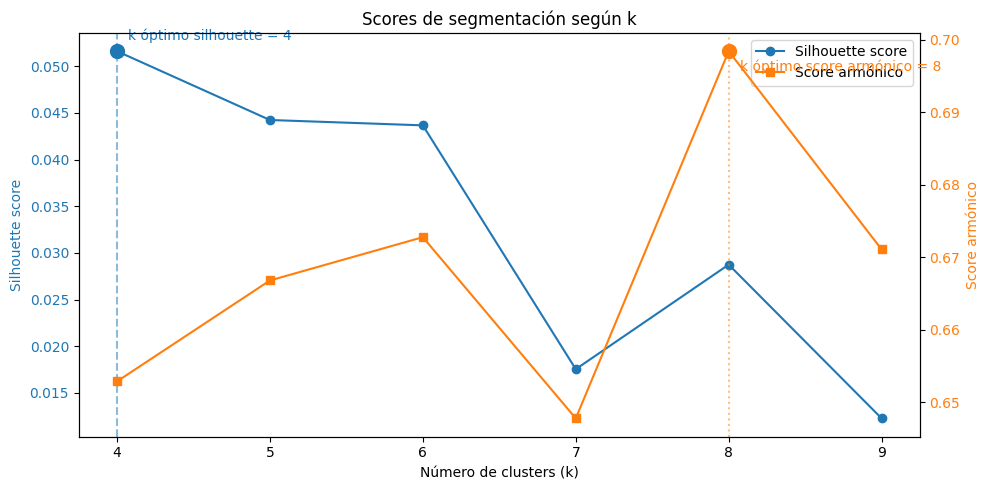

In [41]:
graficar_resultado(resultados_segmentacion)

In [42]:
k_elegido = 7
segmentacion_clientes = segmentar(
    matriz_cliente_sku,
    k_elegido,
    verbosity=verbosity,
)

In [43]:
# Tabla con porcentaje de clientes por TipoNeg en cada cluster
tabla_negocio_cluster (segmentacion_clientes)

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster predominante (%)
DesTipoNeg,,,,,,,,
AL - ALMACÉN,12.8,13.3,17.7,14.6,11.4,19.9,10.2,Cluster 6 (19.9%)
CA - CARNICERÍA,11.3,8.1,10.1,16.3,9.1,6.7,38.4,Cluster 7 (38.4%)
FI - FIAMBRERÍA,30.6,14.4,17.5,12.5,10.0,5.0,10.0,Cluster 1 (30.6%)
FS - FUENTEDE SODA,0.0,0.0,0.0,0.0,0.0,100.0,0.0,Cluster 6 (100.0%)
MA - MAYORISTA,100.0,0.0,0.0,0.0,0.0,0.0,0.0,Cluster 1 (100.0%)
MK - MINIMARKET,12.4,2.9,30.3,6.5,8.5,36.0,3.4,Cluster 6 (36.0%)
PA - PANADERÍA,28.0,20.3,12.2,6.6,17.5,12.0,3.4,Cluster 1 (28.0%)
PZ - PIZZERIA,100.0,0.0,0.0,0.0,0.0,0.0,0.0,Cluster 1 (100.0%)
SL - SUPERMERCADO LOCAL,1.9,0.5,18.8,0.0,2.4,75.8,0.5,Cluster 6 (75.8%)


In [44]:
tabla_cluster_negocio(segmentacion_clientes)

DesTipoNeg,AL - ALMACÉN,CA - CARNICERÍA,FI - FIAMBRERÍA,FS - FUENTEDE SODA,MA - MAYORISTA,MK - MINIMARKET,PA - PANADERÍA,PZ - PIZZERIA,SL - SUPERMERCADO LOCAL,Sin TipoNeg,Tipo negocio principal (%)
Cluster 1,72.4,1.8,0.9,0.0,0.0,2.8,12.7,0.0,0.1,9.2,AL - ALMACÉN (72.4%)
Cluster 2,77.6,1.4,0.4,0.0,0.0,0.7,9.5,0.0,0.0,10.4,AL - ALMACÉN (77.6%)
Cluster 3,82.0,1.4,0.4,0.0,0.0,5.5,4.5,0.0,0.6,5.6,AL - ALMACÉN (82.0%)
Cluster 4,80.3,2.6,0.4,0.0,0.0,1.4,2.9,0.0,0.0,12.4,AL - ALMACÉN (80.3%)
Cluster 5,78.6,1.8,0.4,0.0,0.0,2.3,9.7,0.0,0.1,7.1,AL - ALMACÉN (78.6%)
Cluster 6,83.0,0.8,0.1,0.0,0.0,5.9,4.1,0.0,2.2,3.9,AL - ALMACÉN (83.0%)
Cluster 7,73.4,8.0,0.4,0.0,0.0,1.0,1.9,0.0,0.0,15.4,AL - ALMACÉN (73.4%)


In [45]:
obtener_canasta(
        1,
        matriz_cliente_sku,
        segmentacion_clientes,
        granularidad_sku,
        verbosity=True
)

,familia_marca,conteo_clientes,porcentaje_clientes_cluster
0,SALAMESLA PREFERIDA,4499,0.840149
1,PATELA PREFERIDA,4382,0.818301
2,JAMON G1LA PREFERIDA,4174,0.779458
3,JAMON G2LA PREFERIDA,3763,0.702708
4,MORTADELASLA PREFERIDA,3642,0.680112
5,VIENESASSAN JORGE,3234,0.603922
6,PATESAN JORGE,3103,0.579458
7,LACTEOSLos Nogales,2914,0.544164
8,SNACKSLA PREFERIDA,2827,0.527918
9,QUESOSLos Nogales,2758,0.515033


Canasta del cluster: <StringArray>
[   'SALAMESLA PREFERIDA',       'PATELA PREFERIDA',   'JAMON G1LA PREFERIDA',
   'JAMON G2LA PREFERIDA', 'MORTADELASLA PREFERIDA',      'VIENESASSAN JORGE',
          'PATESAN JORGE',     'LACTEOSLos Nogales',     'SNACKSLA PREFERIDA',
      'QUESOSLos Nogales']
Length: 10, dtype: str


<StringArray>
[   'SALAMESLA PREFERIDA',       'PATELA PREFERIDA',   'JAMON G1LA PREFERIDA',
   'JAMON G2LA PREFERIDA', 'MORTADELASLA PREFERIDA',      'VIENESASSAN JORGE',
          'PATESAN JORGE',     'LACTEOSLos Nogales',     'SNACKSLA PREFERIDA',
      'QUESOSLos Nogales']
Length: 10, dtype: str